# Extended Data 2 — Fragility and exposure sensitivity

This notebook contains diagnostics supporting Main Figure 1. It first tests whether observed losses follow the monotonic boundary-distance gradient expected under a simple independent wildland-source model, then asks whether structures with the same urban depth share neighborhood outcomes. It next tests whether realized geometric coupling contains information beyond conventional proximity and neighborhood-density measures and whether fitted cross-fire thresholds depend on using an asymmetric five- rather than symmetric four-parameter logistic curve.

In [1]:
import json
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from src.analysis.neighborhood import (
    DEFAULT_RADII_FT, attach_damaged_neighbor_counts,
    neighborhood_exposure_summary,
)
from src.analysis.fragility_sensitivity import compare_4pl_5pl
from src.analysis.population_audit import sha256
from src.viz.extended_data import plot_neighbor_radius_sweep
from src.viz.fragility_sensitivity import plot_4pl_5pl_comparison
from src.viz.style import FIRE_COLORS, WUI_INFLUENCE_COLOR, apply_style

apply_style()
DATA = PROJECT_ROOT / 'data'
RESULTS = PACKAGE_ROOT / 'results'
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
for directory in [RESULTS, FIGURES, SOURCE_DATA]:
    directory.mkdir(parents=True, exist_ok=True)

FIRES = ('EATON', 'PALISADES')
FIRE_COLOR = FIRE_COLORS
M_TO_FT = 3.28084
M_PER_MI = 1609.344
INFLUENCE_OPENING_M = 100.0
DEPTH_LABELS = {
    'dist_to_opened_influence_boundary_m':
        'nearest fire-clipped Influence boundary',
}

analysis = pd.read_parquet(DATA / 'analysis.parquet')
analysis['BLD_ID'] = analysis.BLD_ID.astype(str)
# NDVI is joined from the dedicated vegetation table below.
analysis_depth = analysis.drop(columns=['ndvi_mean'], errors='ignore')
depth_map_source = pd.read_csv(
    SOURCE_DATA / 'ED_fig_urban_depth_maps_source.csv',
    dtype={'BLD_ID': str})
geometry_parts = []
for fire_name in FIRES:
    buildings = gpd.read_parquet(
        DATA / 'nx' / f'{fire_name}_buildings.parquet',
        columns=['BLD_ID', 'geometry']).to_crs(26911)
    buildings['BLD_ID'] = buildings.BLD_ID.astype(str)
    buildings['fire'] = fire_name
    geometry_parts.append(buildings.drop_duplicates('BLD_ID'))
building_geometry = gpd.GeoDataFrame(
    pd.concat(geometry_parts, ignore_index=True), geometry='geometry',
    crs=26911)
urban_depth_buildings = (
    building_geometry
    .merge(depth_map_source, on=['BLD_ID', 'fire'], how='inner',
           validate='one_to_one')
    .merge(analysis_depth[[
        'BLD_ID', 'fire', 'is_destroyed', 'any_damage', 'grid_id']],
        on=['BLD_ID', 'fire'], how='inner', validate='one_to_one'))

wui_zones = gpd.read_file(DATA / 'calfire_wui_la.gpkg').to_crs(26911)
influence_zone = wui_zones[wui_zones.WUI_DESC.eq('Influence Zone')]
fire_perimeters_depth = (
    gpd.read_parquet(DATA / 'nx' / 'fire_perims.parquet')
    .to_crs(26911).set_index('FIRE_NAME'))
opened_influence_zones = {}
for fire_name in FIRES:
    clipped = shapely.intersection(
        influence_zone.geometry.union_all(),
        fire_perimeters_depth.loc[fire_name].geometry)
    opened = shapely.buffer(
        shapely.buffer(clipped, -INFLUENCE_OPENING_M),
        INFLUENCE_OPENING_M)
    opened_influence_zones[fire_name] = gpd.GeoSeries(
        [opened], crs=26911)


### Structure loss and potential coupling across urban depth

The preceding figure establishes the outcome gradient but does not show how the built environment changes along it. This synthesis aligns total destruction, total potential structural coupling, $F_{\mathrm{total}}$, and pre-fire near-structure NDVI on the same urban-depth bins. It is intentionally distinct from the later shared-neighborhood-loss figure: the lower rows describe pre-outcome structural and vegetation conditions rather than the observed fate of neighboring structures.

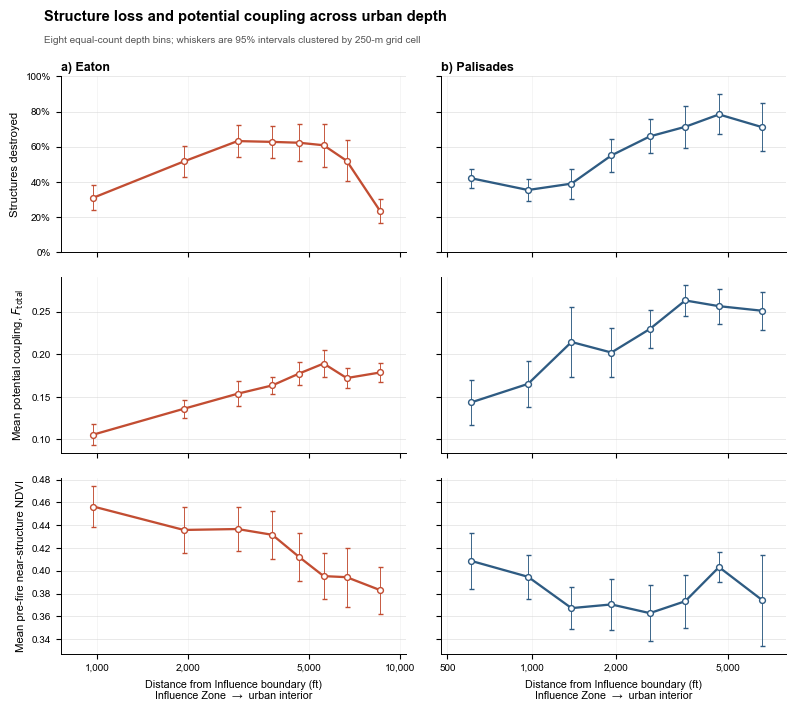

,fire,depth_bin,buildings,clusters_250m,depth_ft,destroyed_share,destroyed_lo,destroyed_hi,F_total_mean,F_total_lo,F_total_hi,ndvi_mean,ndvi_lo,ndvi_hi
0,EATON,0,2107,153,973.3298,0.3113,0.2396,0.3831,0.1057,0.0934,0.1181,0.4564,0.4381,0.4747
1,EATON,1,2106,96,1932.0536,0.5171,0.4284,0.6058,0.1360,0.1254,0.1467,0.4359,0.4160,0.4557
2,EATON,2,2106,81,2905.7728,0.6330,0.5406,0.7253,0.1537,0.1393,0.1682,0.4367,0.4177,0.4557
3,EATON,3,2107,68,3781.7112,0.6284,0.5380,0.7187,0.1635,0.1533,0.1737,0.4316,0.4108,0.4524
4,EATON,4,2106,62,4637.2600,0.6235,0.5197,0.7272,0.1775,0.1637,0.1913,0.4121,0.3910,0.4333
5,EATON,5,2106,59,5584.3464,0.6092,0.4868,0.7316,0.1893,0.1737,0.2048,0.3954,0.3754,0.4154
6,EATON,6,2106,63,6650.6651,0.5209,0.4034,0.6384,0.1722,0.1600,0.1844,0.3944,0.3686,0.4203
7,EATON,7,2107,49,8567.9764,0.2359,0.1651,0.3066,0.1787,0.1675,0.1900,0.3831,0.3625,0.4038
8,PALISADES,0,1420,303,607.0082,0.4218,0.3688,0.4748,0.1435,0.1169,0.1702,0.4088,0.3839,0.4336
9,PALISADES,1,1420,207,968.5795,0.3549,0.2929,0.4169,0.1653,0.1384,0.1922,0.3948,0.3756,0.4139


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_urban_depth_structure_loss_coupling.png


In [2]:
from matplotlib.ticker import FixedFormatter, FixedLocator

DEPTH_COUPLING_BINS = 8
radex_depth = pd.read_parquet(
    DATA / 'radex.parquet',
    columns=['BLD_ID', 'fire', 'F_total_wmean'])
radex_depth['BLD_ID'] = radex_depth.BLD_ID.astype(str)
radex_depth = radex_depth.drop_duplicates(['BLD_ID', 'fire'])
vegetation_depth = pd.read_parquet(
    DATA / 'enrichment' / 'vegetation.parquet',
    columns=['BLD_ID', 'ndvi_mean'])
vegetation_depth['BLD_ID'] = vegetation_depth.BLD_ID.astype(str)
vegetation_depth = vegetation_depth.drop_duplicates('BLD_ID')
# Reuse the per-building depth source produced by the spatial audit. This
# avoids repeating the polygon-nearest calculation for a synthesis figure.
depth_map_source = pd.read_csv(
    SOURCE_DATA / 'ED_fig_urban_depth_maps_source.csv',
    dtype={'BLD_ID': str})
urban_depth_coupling = (
    depth_map_source
    .merge(analysis_depth, on=['BLD_ID', 'fire'], how='inner',
           validate='one_to_one')
    .merge(radex_depth, on=['BLD_ID', 'fire'], how='left',
           validate='one_to_one')
    .merge(vegetation_depth, on='BLD_ID', how='left',
           validate='one_to_one'))
urban_depth_coupling = urban_depth_coupling.dropna(
    subset=['dist_to_opened_influence_boundary_m', 'F_total_wmean',
            'is_destroyed', 'ndvi_mean']).copy()
urban_depth_coupling['depth_ft'] = (
    urban_depth_coupling.dist_to_opened_influence_boundary_m * M_TO_FT)
urban_depth_coupling = urban_depth_coupling[
    urban_depth_coupling.depth_ft.gt(0)].copy()
urban_depth_coupling['ln_depth'] = np.log(
    urban_depth_coupling.depth_ft)
urban_depth_coupling['depth_bin'] = (
    urban_depth_coupling.groupby('fire').ln_depth
    .transform(lambda values: pd.qcut(
        values, DEPTH_COUPLING_BINS, labels=False, duplicates='drop')))


def _grid_clustered_mean(group, column, bounded=False):
    values = group[column].to_numpy(float)
    estimate = float(np.mean(values))
    cluster = group.grid_id.fillna(group.BLD_ID).astype(str)
    scores = (pd.Series(values - estimate, index=group.index)
              .groupby(cluster).sum().to_numpy())
    n_clusters = len(scores)
    se = (np.sqrt(n_clusters / (n_clusters - 1)
                  * np.sum(scores ** 2) / len(group) ** 2)
          if n_clusters > 1 else np.nan)
    lo, hi = estimate - 1.96 * se, estimate + 1.96 * se
    if bounded:
        lo, hi = max(0., lo), min(1., hi)
    return estimate, lo, hi, n_clusters


depth_coupling_rows = []
for (fire_name, depth_bin), group in urban_depth_coupling.groupby(
        ['fire', 'depth_bin'], observed=True):
    destroyed, destroyed_lo, destroyed_hi, n_clusters = (
        _grid_clustered_mean(group, 'is_destroyed', bounded=True))
    potential, potential_lo, potential_hi, _ = (
        _grid_clustered_mean(group, 'F_total_wmean'))
    vegetation, vegetation_lo, vegetation_hi, _ = (
        _grid_clustered_mean(group, 'ndvi_mean'))
    depth_coupling_rows.append({
        'fire': fire_name, 'depth_bin': int(depth_bin),
        'buildings': len(group), 'clusters_250m': n_clusters,
        'depth_ft': float(np.exp(group.ln_depth.mean())),
        'destroyed_share': destroyed,
        'destroyed_lo': destroyed_lo, 'destroyed_hi': destroyed_hi,
        'F_total_mean': potential,
        'F_total_lo': potential_lo, 'F_total_hi': potential_hi,
        'ndvi_mean': vegetation,
        'ndvi_lo': vegetation_lo, 'ndvi_hi': vegetation_hi,
    })
depth_coupling_profile = pd.DataFrame(depth_coupling_rows)
depth_coupling_profile.to_csv(
    RESULTS / 'ED02_urban_depth_structure_loss_coupling.csv', index=False)
depth_coupling_profile.to_csv(
    SOURCE_DATA / 'ED_fig_urban_depth_structure_loss_coupling_source.csv',
    index=False)

fig, axes = plt.subplots(3, 2, figsize=(8.2, 7.4), sharex='col',
                         sharey='row')
for col, fire_name in enumerate(FIRES):
    profile = depth_coupling_profile[
        depth_coupling_profile.fire.eq(fire_name)
    ].sort_values('depth_ft')
    color = FIRE_COLOR[fire_name]
    specifications = [
        (axes[0, col], 'destroyed_share', 'destroyed_lo', 'destroyed_hi'),
        (axes[1, col], 'F_total_mean', 'F_total_lo', 'F_total_hi'),
        (axes[2, col], 'ndvi_mean', 'ndvi_lo', 'ndvi_hi'),
    ]
    for ax, value, lower, upper in specifications:
        yerr = np.vstack([profile[value] - profile[lower],
                          profile[upper] - profile[value]])
        ax.errorbar(
            profile.depth_ft, profile[value],
            yerr=np.clip(yerr, 0, None), color=color, marker='o',
            ms=4.2, mfc='white', mew=1.0, lw=1.65,
            elinewidth=.65, capsize=1.8, zorder=3)
        ax.set_xscale('log')
        ax.set_xlim(profile.depth_ft.min() * .78,
                    profile.depth_ft.max() * 1.22)
        ax.grid(axis='y', color='#D8D8D8', lw=.5, alpha=.8)
        ax.grid(axis='x', color='#E8E8E8', lw=.4, alpha=.7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7.2)
    axes[0, col].set_title(
        f'{chr(97 + col)}) {fire_name.title()}', loc='left',
        fontsize=9.0, fontweight='bold', pad=4)
    axes[0, col].set_ylim(0, 1)
    ticks = ([500, 1_000, 2_000, 5_000, 10_000]
             if fire_name == 'EATON' else [300, 500, 1_000, 2_000, 5_000])
    ticks = [tick for tick in ticks
             if profile.depth_ft.min() * .8 <= tick <= profile.depth_ft.max() * 1.2]
    axes[2, col].xaxis.set_major_locator(FixedLocator(ticks))
    axes[2, col].xaxis.set_major_formatter(FixedFormatter(
        [f'{tick:,}' for tick in ticks]))
    axes[2, col].xaxis.set_minor_locator(FixedLocator([]))
    axes[2, col].set_xlabel(
        'Distance from Influence boundary (ft)\n'
        'Influence Zone  \u2192  urban interior', fontsize=7.7, labelpad=5)
axes[0, 0].set_ylabel('Structures destroyed', fontsize=8.2)
axes[0, 0].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[1, 0].set_ylabel(r'Mean potential coupling, $F_{\mathrm{total}}$',
                      fontsize=8.2)
axes[2, 0].set_ylabel('Mean pre-fire near-structure NDVI', fontsize=8.2)
fig.suptitle('Structure loss and potential coupling across urban depth',
             x=.085, ha='left', y=.99, fontsize=10.6, fontweight='bold')
fig.text(.085, .945,
         'Eight equal-count depth bins; whiskers are 95% intervals clustered by 250-m grid cell',
         ha='left', fontsize=7.2, color='#555555')
fig.subplots_adjust(left=.105, right=.99, top=.90, bottom=.12,
                    hspace=.14, wspace=.10)
depth_coupling_stem = FIGURES / 'ED_fig_urban_depth_structure_loss_coupling'
fig.savefig(depth_coupling_stem.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(depth_coupling_stem.with_suffix('.png'), dpi=300,
            bbox_inches='tight')
plt.show()
display(depth_coupling_profile.round(4))
print('saved', depth_coupling_stem.with_suffix('.png'))

### Spatial distribution of urban depth

The maps show nearest distance to the cleaned, fire-clipped Influence boundary for Eaton and Palisades. Colors are normalized independently within each panel to its 98th percentile because the fires span different ranges; the annotated color-bar maximum should therefore be used for quantitative comparison. The maps are combined with the corresponding neighborhood-loss profiles below.

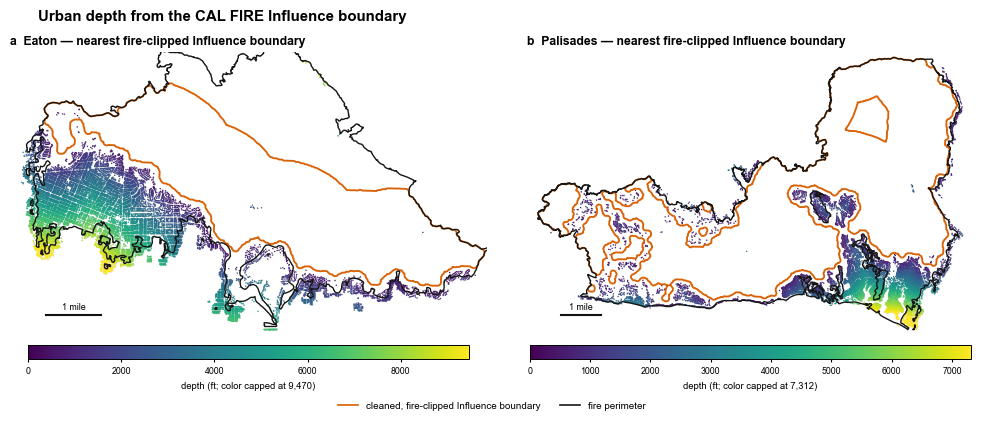

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_urban_depth_metric_maps.png


In [3]:
from matplotlib.cm import ScalarMappable

depth_map_source = urban_depth_buildings[[
    'BLD_ID', 'fire', *DEPTH_LABELS]].copy()
depth_map_source.to_csv(
    SOURCE_DATA / 'ED_fig_urban_depth_maps_source.csv', index=False)
fire_perimeters = fire_perimeters_depth

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
map_cmap = plt.get_cmap('viridis')
panel_letters = iter('ab')
panel_titles = []
for row, (metric, metric_label) in enumerate(DEPTH_LABELS.items()):
    for col, fire_name in enumerate(FIRES):
        ax = axes[col]
        letter = next(panel_letters)
        sub = urban_depth_buildings[
            urban_depth_buildings.fire.eq(fire_name)].copy()
        sub['_depth_ft'] = sub[metric] * M_TO_FT
        values_ft = sub['_depth_ft']
        finite = np.isfinite(values_ft)
        vmax = float(np.nanquantile(values_ft, .98))
        norm = Normalize(vmin=0, vmax=vmax, clip=True)
        # Footprints are far below one pixel at this extent, so the fabric
        # reads as faint hatching. One centroid per structure keeps the same
        # density but gives every building a visible mark.
        centroids = sub.geometry.centroid
        sub['_x'], sub['_y'] = centroids.x, centroids.y
        ax.scatter(sub._x, sub._y, s=1.0, c='#E2E2DE', linewidths=0,
                   rasterized=True, zorder=2)
        ax.scatter(sub.loc[finite, '_x'], sub.loc[finite, '_y'],
                   c=values_ft[finite], cmap=map_cmap, norm=norm, s=1.0,
                   linewidths=0, rasterized=True, zorder=3)

        xmin, ymin, xmax, ymax = sub.total_bounds
        xpad, ypad = .025 * (xmax - xmin), .035 * (ymax - ymin)
        local_boundary = influence_zone.cx[
            xmin - xpad:xmax + xpad, ymin - ypad:ymax + ypad]
        if metric == 'dist_to_opened_influence_boundary_m':
            opened_influence_zones[fire_name].boundary.plot(
                ax=ax, color=WUI_INFLUENCE_COLOR, lw=1.35, alpha=.98, zorder=5)
        else:
            local_boundary.boundary.plot(
                ax=ax, color=WUI_INFLUENCE_COLOR, lw=.55, alpha=.55, zorder=4)
        if fire_name in fire_perimeters.index:
            gpd.GeoSeries(
                [fire_perimeters.loc[fire_name].geometry],
                crs=fire_perimeters.crs).boundary.plot(
                    ax=ax, color='#161616', lw=1.0, zorder=5)
        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        panel_titles.append(
            (ax, f'{letter}  {fire_name.title()} — {metric_label}'))
        bar_x0 = xmin + .055 * (xmax - xmin)
        bar_y = ymin + .055 * (ymax - ymin)
        ax.plot([bar_x0, bar_x0 + M_PER_MI], [bar_y, bar_y],
                color='#111111', lw=1.5, zorder=7)
        ax.text(bar_x0 + M_PER_MI / 2, bar_y + .018 * (ymax - ymin),
                '1 mile', ha='center', va='bottom', fontsize=6.4)
        cbar = fig.colorbar(
            ScalarMappable(norm=norm, cmap=map_cmap), ax=ax,
            orientation='horizontal', fraction=.045, pad=.018, aspect=32)
        cbar.set_label(f'depth (ft; color capped at {vmax:,.0f})',
                       fontsize=6.8)
        cbar.ax.tick_params(labelsize=6.3, length=2)

legend_handles = [
    Line2D([0], [0], color=WUI_INFLUENCE_COLOR, lw=1.2,
           label='cleaned, fire-clipped Influence boundary'),
    Line2D([0], [0], color='#161616', lw=1.2, label='fire perimeter'),
]
fig.legend(handles=legend_handles, frameon=False, loc='lower center',
           ncol=2, fontsize=7.1, bbox_to_anchor=(.5, .012))
fig.suptitle('Urban depth from the CAL FIRE Influence boundary',
             x=.055, ha='left', y=.988, fontsize=10.8, fontweight='bold')
fig.subplots_adjust(left=.025, right=.99, top=.885, bottom=.155,
                    wspace=.04)
# Equal aspect resizes each axes box to its own map shape at draw time, so a
# title attached to the axes sits at a different height in each panel. Draw
# once to settle the boxes, then put both titles on the taller panel's top.
fig.canvas.draw()
title_y = max(ax.get_position().y1 for ax, _ in panel_titles) + .012
for ax, text in panel_titles:
    fig.text(ax.get_position().x0, title_y, text, ha='left', va='bottom',
             fontsize=8.8, fontweight='bold')
map_stem = FIGURES / 'ED_fig_urban_depth_metric_maps'
fig.savefig(map_stem.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(map_stem.with_suffix('.png'), dpi=300, bbox_inches='tight')
plt.show()
print('saved', map_stem.with_suffix('.png'))


## Proximity-based shared neighborhood loss

LARIAC building footprints were used to identify assessed neighbors within 30.5 m (100 ft) surface-to-surface, corresponding to the outer Home Ignition Zone. The focal building was excluded. Within each fire and urban-depth bin, profiles compare the destroyed share of neighboring assessed structures around focal buildings that survived or were destroyed. A third profile pools all assessed focal structures, providing the overall neighborhood-destruction gradient without conditioning on focal outcome. Confidence intervals for the outcome-stratified profiles use standard errors clustered by approximately 250-m grid cells.

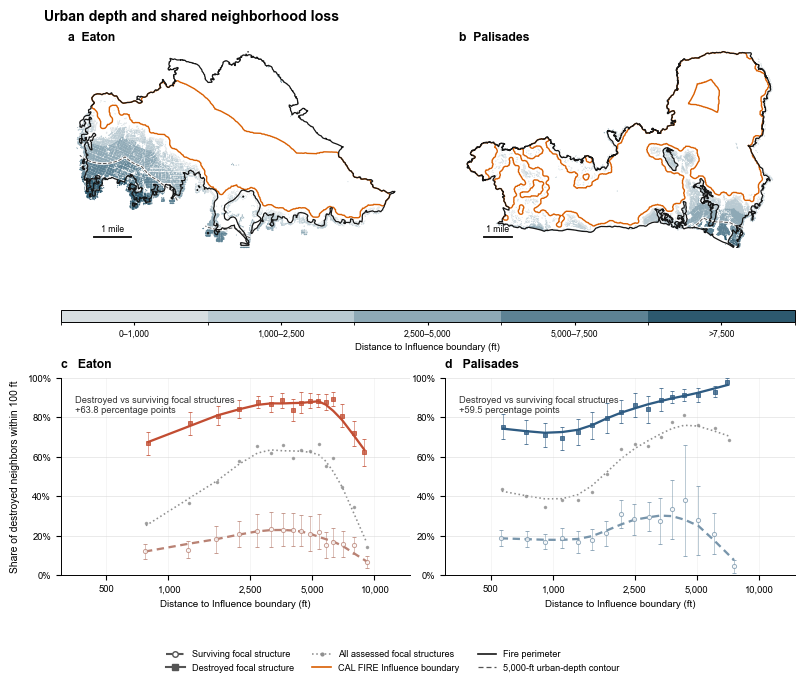

,fire,assessed_buildings,buildings_with_assessed_neighbor,coverage_share,median_assessed_neighbors,mean_assessed_neighbors
0,EATON,16851,16760,0.995,8.0,8.253
1,PALISADES,11357,11035,0.972,7.0,7.368


,metric,fire,matched_depth_bins,destroyed_survived_neighbor_gap_pp
0,dist_to_opened_influence_boundary_m,EATON,16,63.75
1,dist_to_opened_influence_boundary_m,PALISADES,16,59.46


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_proximity_shared_loss_100ft.png


In [4]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
import matplotlib.tri as mtri
from matplotlib.ticker import FixedFormatter, FixedLocator
from statsmodels.nonparametric.smoothers_lowess import lowess

NEIGHBOR_RADIUS_FT = 100
NEIGHBOR_RADIUS_M = NEIGHBOR_RADIUS_FT / M_TO_FT
DEPTH_CONTOUR_FT = 5000
DEPTH_CONTOUR_MAX_EDGE_M = 500
DEPTH_DISPLAY = {
    'dist_to_opened_influence_boundary_m': {
        'label': 'Distance to Influence boundary (ft)',
        'ticks': [500, 1000, 2500, 5000, 10000],
        'xlim': (300, 15000),
    },
}
OUTCOME_STYLE = {
    0: {'label': 'Surviving focal structure', 'marker': 'o', 'ls': (0, (3.2, 2.0)),
        'filled': False, 'color': '#4F7185'},
    1: {'label': 'Destroyed focal structure', 'marker': 's', 'ls': '-',
        'filled': True, 'color': '#A64B3C'},
}
ALL_ASSESSED_COLOR = '#8F8F8F'

neighbor_parts, neighbor_coverage_rows = [], []
for fire_name in FIRES:
    buildings = urban_depth_buildings[
        urban_depth_buildings.fire.eq(fire_name)].copy().reset_index(drop=True)
    pair_idx = buildings.sindex.query(
        buildings.geometry, predicate='dwithin', distance=NEIGHBOR_RADIUS_M)
    keep = pair_idx[0] != pair_idx[1]
    focal_i, neighbor_i = pair_idx[0, keep], pair_idx[1, keep]
    neighbor_count = np.bincount(focal_i, minlength=len(buildings)).astype(int)
    destroyed_count = np.bincount(
        focal_i,
        weights=buildings.is_destroyed.to_numpy(float)[neighbor_i],
        minlength=len(buildings))
    buildings['assessed_neighbors_100ft'] = neighbor_count
    buildings['destroyed_neighbors_100ft'] = destroyed_count.astype(int)
    buildings['destroyed_neighbor_share_100ft'] = np.divide(
        destroyed_count, neighbor_count,
        out=np.full(len(buildings), np.nan, dtype=float),
        where=neighbor_count > 0)
    valid = neighbor_count > 0
    neighbor_coverage_rows.append({
        'fire': fire_name, 'assessed_buildings': len(buildings),
        'buildings_with_assessed_neighbor': int(valid.sum()),
        'coverage_share': float(valid.mean()),
        'median_assessed_neighbors': float(np.median(neighbor_count[valid])),
        'mean_assessed_neighbors': float(np.mean(neighbor_count[valid])),
    })
    neighbor_parts.append(pd.DataFrame(buildings.drop(columns='geometry')))


proximity_outcomes = pd.concat(neighbor_parts, ignore_index=True)
proximity_coverage = pd.DataFrame(neighbor_coverage_rows)
profile_rows, pooled_profile_rows, gap_rows = [], [], []
for metric, metric_spec in DEPTH_DISPLAY.items():
    for fire_name in FIRES:
        z = proximity_outcomes.dropna(
            subset=[metric, 'destroyed_neighbor_share_100ft'])
        z = z[z.fire.eq(fire_name) & z[metric].gt(0)].copy()
        z['depth_ft'] = z[metric] * M_TO_FT
        z['ln_depth'] = np.log(z.depth_ft)
        z['depth_bin'] = pd.qcut(
            z.ln_depth, 16, labels=False, duplicates='drop')
        # The reference series uses the same assessed focal population as the
        # outcome-stratified curves, pooled over focal outcome.
        for depth_bin, group in z.groupby('depth_bin', observed=True):
            pooled_profile_rows.append({
                'metric': metric, 'fire': fire_name,
                'depth_bin': int(depth_bin), 'buildings': len(group),
                'depth_ft': np.exp(group.ln_depth.mean()),
                'ln_depth': group.ln_depth.mean(),
                'destroyed_neighbor_share_100ft':
                    group.destroyed_neighbor_share_100ft.mean(),
                'mean_assessed_neighbors':
                    group.assessed_neighbors_100ft.mean(),
            })
        fire_rows = []
        for (damage, depth_bin), group in z.groupby(
                ['is_destroyed', 'depth_bin'], observed=True):
            if len(group) < 30:
                continue
            y = group.destroyed_neighbor_share_100ft.to_numpy(float)
            ybar = float(np.mean(y))
            cluster = group.grid_id.fillna(group.BLD_ID).astype(str)
            scores = (pd.Series(y - ybar, index=group.index)
                      .groupby(cluster).sum().to_numpy())
            n_clusters = len(scores)
            se = (np.sqrt(
                n_clusters / (n_clusters - 1)
                * np.sum(scores ** 2) / len(group) ** 2)
                  if n_clusters > 1 else np.nan)
            row = {
                'metric': metric, 'fire': fire_name,
                'is_destroyed': int(damage), 'depth_bin': int(depth_bin),
                'buildings': len(group), 'clusters_250m': n_clusters,
                'depth_ft': np.exp(group.ln_depth.mean()),
                'destroyed_neighbor_share_100ft': ybar,
                'share_lo': max(0, ybar - 1.96 * se),
                'share_hi': min(1, ybar + 1.96 * se),
                'mean_assessed_neighbors': group.assessed_neighbors_100ft.mean(),
                'ln_depth': group.ln_depth.mean(),
            }
            fire_rows.append(row); profile_rows.append(row)
        fire_profile = pd.DataFrame(fire_rows)
        paired = fire_profile.pivot(
            index='depth_bin', columns='is_destroyed',
            values='destroyed_neighbor_share_100ft').dropna()
        gap_rows.append({
            'metric': metric, 'fire': fire_name,
            'matched_depth_bins': len(paired),
            'destroyed_survived_neighbor_gap_pp':
                float(100 * (paired[1] - paired[0]).mean()),
        })

proximity_profile = pd.DataFrame(profile_rows)
all_assessed_profile = pd.DataFrame(pooled_profile_rows)
proximity_gap = pd.DataFrame(gap_rows)
proximity_coverage.to_csv(
    RESULTS / 'ED02_proximity_neighbor_coverage_100ft.csv', index=False)
proximity_profile.to_csv(
    RESULTS / 'ED02_proximity_shared_loss_profiles.csv', index=False)
proximity_gap.to_csv(
    RESULTS / 'ED02_proximity_shared_loss_gaps.csv', index=False)
proximity_profile.to_csv(
    SOURCE_DATA / 'ED_fig_proximity_shared_loss_source.csv', index=False)
all_assessed_profile.to_csv(
    SOURCE_DATA / 'ED_fig_proximity_all_assessed_source.csv', index=False)

fig = plt.figure(figsize=(8.2, 6.8))
grid = fig.add_gridspec(3, 2, height_ratios=[1.02, .055, .96],
                        hspace=.40, wspace=.10)
axes = np.array([[fig.add_subplot(grid[0, 0]),
                  fig.add_subplot(grid[0, 1])],
                 [fig.add_subplot(grid[2, 0]),
                  fig.add_subplot(grid[2, 1])]])
colorbar_ax = fig.add_subplot(grid[1, :])
map_metric = 'dist_to_opened_influence_boundary_m'
DEPTH_BINS_FT = np.array([0, 1000, 2500, 5000, 7500, 10000])
MAP_COLORS = ['#D7DEE1', '#B9CAD2', '#8EA9B6', '#5D8294', '#2D596E']
map_cmap = ListedColormap(MAP_COLORS)
map_norm = BoundaryNorm(DEPTH_BINS_FT, map_cmap.N, clip=True)
FIRE_LIGHT = {'EATON': '#B98274', 'PALISADES': '#7895AB'}
for col_i, fire_name in enumerate(FIRES):
    ax = axes[0, col_i]
    sub = urban_depth_buildings[
        urban_depth_buildings.fire.eq(fire_name)].copy()
    sub['_depth_ft'] = sub[map_metric] * M_TO_FT
    values_ft = sub['_depth_ft'].to_numpy(float)
    # Plot one centroid per assessed structure. At the fire-wide extent,
    # individual footprints become thin, uneven marks and obscure the
    # spatial depth pattern. Equal-sized centroids remain legible.
    sub_points = sub.copy()
    sub_points.geometry = sub.geometry.centroid
    sub_points.plot(
        ax=ax, column='_depth_ft', cmap=map_cmap, norm=map_norm,
        marker='o', markersize=.45, linewidth=0, edgecolor='none',
        alpha=.92, rasterized=True, zorder=2)
    opened_influence_zones[fire_name].boundary.plot(
        ax=ax, color=WUI_INFLUENCE_COLOR, lw=1.0, zorder=4)
    # A single haloed isodepth line provides a common spatial reference
    # without duplicating the 2,500-ft break already encoded by color.
    # It is interpolated over assessed-building locations; triangles with
    # long edges are masked to avoid bridging disconnected neighborhoods.
    contour_points = sub_points.geometry
    contour_x = contour_points.x.to_numpy(float)
    contour_y = contour_points.y.to_numpy(float)
    contour_valid = (np.isfinite(contour_x) & np.isfinite(contour_y)
                     & np.isfinite(values_ft))
    contour_values = values_ft[contour_valid]
    triangulation = mtri.Triangulation(
        contour_x[contour_valid], contour_y[contour_valid])
    triangle_xy = np.stack([
        triangulation.x[triangulation.triangles],
        triangulation.y[triangulation.triangles]], axis=2)
    triangle_edges = np.stack([
        triangle_xy[:, 1] - triangle_xy[:, 0],
        triangle_xy[:, 2] - triangle_xy[:, 1],
        triangle_xy[:, 0] - triangle_xy[:, 2]], axis=1)
    longest_edge = np.sqrt((triangle_edges ** 2).sum(axis=2)).max(axis=1)
    triangulation.set_mask(longest_edge > DEPTH_CONTOUR_MAX_EDGE_M)
    if contour_values.min() <= DEPTH_CONTOUR_FT <= contour_values.max():
        ax.tricontour(
            triangulation, contour_values, levels=[DEPTH_CONTOUR_FT],
            colors='white', linewidths=1.8, zorder=4.8)
        ax.tricontour(
            triangulation, contour_values, levels=[DEPTH_CONTOUR_FT],
            colors='#555555', linewidths=.72,
            linestyles='dashed', zorder=5.0)
    gpd.GeoSeries([fire_perimeters_depth.loc[fire_name].geometry],
                  crs=26911).boundary.plot(
        ax=ax, color='#161616', lw=.9, zorder=6)
    # Include the complete mapped fire perimeter in the viewport so the
    # Eaton boundary is not clipped by the assessed-building extent.
    building_bounds = sub.total_bounds
    perimeter_bounds = np.asarray(
        fire_perimeters_depth.loc[fire_name].geometry.bounds)
    xmin = min(building_bounds[0], perimeter_bounds[0])
    ymin = min(building_bounds[1], perimeter_bounds[1])
    xmax = max(building_bounds[2], perimeter_bounds[2])
    ymax = max(building_bounds[3], perimeter_bounds[3])
    xpad, ypad = .025 * (xmax - xmin), .035 * (ymax - ymin)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_title(f'{"ab"[col_i]}  {fire_name.title()}', loc='left',
                 fontsize=8.8, fontweight='bold', pad=3)
    bar_x0 = xmin + .055 * (xmax - xmin)
    bar_y = ymin + .055 * (ymax - ymin)
    ax.plot([bar_x0, bar_x0 + M_PER_MI], [bar_y, bar_y],
            color='#111111', lw=1.35, zorder=7)
    ax.text(bar_x0 + M_PER_MI / 2, bar_y + .018 * (ymax - ymin),
            '1 mile', ha='center', va='bottom', fontsize=6.2)
depth_cbar = fig.colorbar(
    ScalarMappable(norm=map_norm, cmap=map_cmap), cax=colorbar_ax,
    orientation='horizontal',
    ticks=[500, 1750, 3750, 6250, 8750])
depth_cbar.set_label('Distance to Influence boundary (ft)',
                     fontsize=6.8, labelpad=3)
depth_cbar.ax.tick_params(labelsize=6.2, length=2)
depth_cbar.ax.set_xticklabels(
    ['0–1,000', '1,000–2,500', '2,500–5,000',
     '5,000–7,500', '>7,500'])
for row_i, (metric, metric_spec) in enumerate(DEPTH_DISPLAY.items()):
    for col_i, fire_name in enumerate(FIRES):
        ax = axes[1, col_i]
        panel = proximity_profile[
            proximity_profile.metric.eq(metric)
            & proximity_profile.fire.eq(fire_name)]
        background = all_assessed_profile[
            all_assessed_profile.fire.eq(fire_name)
            & all_assessed_profile.metric.eq(metric)
        ].sort_values('depth_ft')
        background_smooth = lowess(
            background.destroyed_neighbor_share_100ft,
            background.ln_depth, frac=.45, return_sorted=True)
        ax.plot(np.exp(background_smooth[:, 0]),
                np.clip(background_smooth[:, 1], 0, 1),
                color=ALL_ASSESSED_COLOR, lw=1.15, ls=':', zorder=1)
        ax.plot(background.depth_ft,
                background.destroyed_neighbor_share_100ft,
                marker='.', ms=3.0, lw=0, color=ALL_ASSESSED_COLOR,
                alpha=.75, zorder=2)
        for damage in [0, 1]:
            style = OUTCOME_STYLE[damage]
            series_color = (FIRE_COLOR[fire_name] if damage == 1
                            else FIRE_LIGHT[fire_name])
            group = panel[
                panel.is_destroyed.eq(damage)].sort_values('depth_ft')
            smooth = lowess(
                group.destroyed_neighbor_share_100ft, group.ln_depth,
                frac=.45, return_sorted=True)
            ax.plot(np.exp(smooth[:, 0]), np.clip(smooth[:, 1], 0, 1),
                    color=series_color, ls=style['ls'], lw=1.65, zorder=3)
            yerr = np.vstack([
                group.destroyed_neighbor_share_100ft - group.share_lo,
                group.share_hi - group.destroyed_neighbor_share_100ft])
            ax.errorbar(
                group.depth_ft, group.destroyed_neighbor_share_100ft,
                yerr=np.clip(yerr, 0, None), fmt=style['marker'],
                ms=3.0, mew=.7, color=series_color,
                ecolor=series_color, elinewidth=.45, alpha=.78,
                capsize=1.2, lw=0,
                mfc=series_color if style['filled'] else 'white',
                zorder=4)
        gap = proximity_gap.loc[
            proximity_gap.metric.eq(metric)
            & proximity_gap.fire.eq(fire_name),
            'destroyed_survived_neighbor_gap_pp'].iloc[0]
        letter = 'cd'[col_i]
        ax.text(0, 1.035, f'{letter}   {fire_name.title()}',
                transform=ax.transAxes, ha='left', va='bottom',
                fontsize=8.8, fontweight='bold', clip_on=False)
        ax.text(.04, .91,
                f'Destroyed vs surviving focal structures\n'
                f'{gap:+.1f} percentage points',
                transform=ax.transAxes, ha='left', va='top', fontsize=6.7,
                color='#333333')
        ax.set_xscale('log'); ax.set_ylim(0, 1)
        ax.set_xlim(*metric_spec['xlim'])
        ax.set_xticks(metric_spec['ticks'])
        ax.xaxis.set_major_formatter(FixedFormatter(
            [f'{value:,}' for value in metric_spec['ticks']]))
        ax.xaxis.set_minor_locator(FixedLocator([]))
        ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
        ax.set_xlabel(metric_spec['label'], labelpad=4, fontsize=7.1)
        ax.grid(axis='y', color='#D7D7D7', lw=.5, alpha=.75)
        ax.grid(axis='x', color='#E5E5E5', lw=.4, alpha=.65)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=6.8)

axes[1, 0].set_ylabel(
    f'Share of destroyed neighbors within {NEIGHBOR_RADIUS_FT} ft',
    labelpad=5, fontsize=7.4)
legend_handles = [
    Line2D([0], [0], color='#555555', lw=1.5, ls=style['ls'],
           marker=style['marker'], markersize=4.0,
           mfc='#555555' if style['filled'] else 'white',
           label=style['label'])
    for style in OUTCOME_STYLE.values()]
legend_handles.append(
    Line2D([0], [0], color=ALL_ASSESSED_COLOR, lw=1.15, ls=':',
           marker='.', markersize=4, label='All assessed focal structures'))
legend_handles.extend([
    Line2D([0], [0], color=WUI_INFLUENCE_COLOR, lw=1.2,
           label='CAL FIRE Influence boundary'),
    Line2D([0], [0], color='#161616', lw=1.2,
           label='Fire perimeter'),
    Line2D([0], [0], color='#555555', lw=.9, ls=(0, (4, 2.4)),
           label='5,000-ft urban-depth contour'),
])
fig.legend(handles=legend_handles, frameon=False, loc='lower center',
           bbox_to_anchor=(.5, .005), ncol=3, fontsize=6.6)
fig.suptitle('Urban depth and shared neighborhood loss', x=.075,
             ha='left', y=.992, fontsize=10.2, fontweight='bold')
fig.subplots_adjust(left=.095, right=.99, top=.94, bottom=.16)
figure_stem = FIGURES / 'ED_fig_proximity_shared_loss_100ft'
fig.savefig(figure_stem.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(figure_stem.with_suffix('.png'), dpi=300, bbox_inches='tight')
plt.show()
display(proximity_coverage.round(3))
display(proximity_gap.round(2))
print('saved', figure_stem.with_suffix('.png'))


If independent ignitions were governed primarily by exposure from mapped wildland fuels, structural loss should generally diminish with urban depth. Instead, damage and total loss persisted deep into the built environment and did not decline monotonically with distance from the fire-clipped CAL FIRE Influence boundary (Extended Data Fig. X). At comparable depths, destroyed focal structures had approximately 59–64 percentage points more destroyed assessed neighbors within 100 ft than surviving focal structures. The profile pooling all assessed focal structures also rose through much of the urban-depth gradient before declining in the outer tail, showing that this pattern was not created solely by stratifying focal buildings by outcome. Together, these patterns show that distance from wildland fuels alone is insufficient to explain the loss distribution and are consistent with local structural fuels contributing increasingly deeper into the built environment. They do not exclude spatially heterogeneous ember exposure or identify transmission between particular buildings; they motivate the subsequent geometric-coupling analysis.

### Restricted to the densely built side of each fire

The preceding profiles pool the whole assessed population, so a persistent
depth gradient could reflect the built fabric changing with depth rather than
depth itself. This diagnostic repeats the same construction on the densely
built side of each burn: western Eaton, which contains the Altadena street
grid, and eastern Palisades, which contains the village core and the Sunset
corridor. Each fire is cut at a quantile of the easting of its own assessed
buildings, the 75th percentile for Eaton and the 25th for Palisades, rather
than at a fraction of the perimeter width, because both perimeters extend into
wildland holding very few structures. `SELECTED_SHARE` sets how much of each
fire is retained; at 0.75 the retained side still carries roughly twice the
local building density of the remainder. Maps show the cut and the selected
buildings; the profiles repeat the destroyed-versus-surviving focal contrast
inside the selected side, with the corresponding curves for the remainder drawn
faintly for reference. Depth bins are re-cut within each side, and local
density, reported as assessed buildings per hectare in the 250 m analysis grid
cell, is carried through as a descriptive check that the selected sides are in
fact the denser ones. Because the remainder is now a quarter of each fire and
contains few destroyed structures, its faint reference curves are noisier than
the selected-side curves and the count of matched depth bins behind each gap is
reported alongside them.

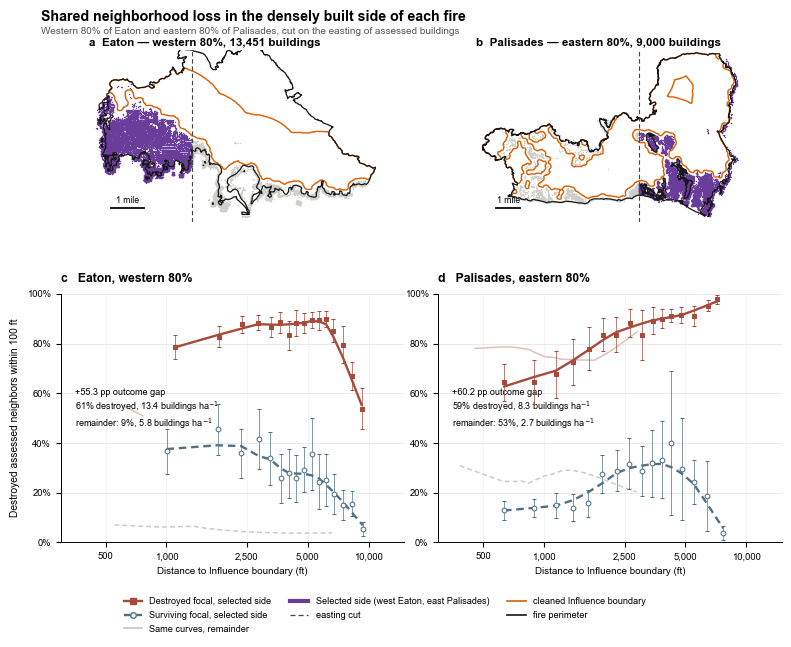

EATON: western 80%, cut at easting 397,490 m (EPSG:26911)
PALISADES: eastern 80%, cut at easting 354,985 m (EPSG:26911)


,fire,selected_side,half,buildings,grid_cells_250m,median_density_per_ha,median_depth_ft,destroyed_share,neighbor_share_destroyed_focal,neighbor_share_surviving_focal,outcome_gap_pp
0,EATON,west,Remainder,3309.0,164.0,5.76,1902.971,0.092,0.501,0.050,45.074
1,EATON,west,Selected,13451.0,244.0,13.44,4575.140,0.615,0.856,0.236,61.983
2,PALISADES,east,Remainder,2035.0,227.0,2.72,1050.999,0.530,0.768,0.265,50.339
3,PALISADES,east,Selected,9000.0,303.0,8.32,2865.682,0.592,0.865,0.200,66.440


,fire,half,matched_depth_bins,destroyed_survived_neighbor_gap_pp
0,EATON,Selected,16,55.26
1,EATON,Remainder,2,46.11
2,PALISADES,Selected,16,60.17
3,PALISADES,Remainder,16,49.99


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_dense_side_shared_loss_100ft.png


In [5]:
GRID_CELL_HA = 6.25  # the 250 m analysis grid used for clustered errors
SIDE = {'EATON': 'west', 'PALISADES': 'east'}
SIDE_LABEL = {'EATON': 'western', 'PALISADES': 'eastern'}
SELECTED_SHARE = .8  # share of each fire's assessed buildings retained
SIDE_BINS = 16

half_points = urban_depth_buildings.geometry.representative_point()
half_outcomes = proximity_outcomes.merge(
    pd.DataFrame({'BLD_ID': urban_depth_buildings.BLD_ID.astype(str),
                  'fire': urban_depth_buildings.fire,
                  'easting': half_points.x.to_numpy(),
                  'northing': half_points.y.to_numpy()}),
    on=['BLD_ID', 'fire'], how='left')
half_outcomes['cell_density_per_ha'] = (
    half_outcomes.groupby(['fire', 'grid_id']).BLD_ID.transform('size')
    / GRID_CELL_HA)

# The cut is a quantile of the easting of assessed buildings, not a fraction of
# the perimeter width, because both perimeters extend into wildland that holds
# very few structures. Each selected side therefore holds SELECTED_SHARE of that
# fire's assessed population, taken from the densely built end.
half_cuts = {}
half_outcomes['half'] = 'Remainder'
for fire_name, side in SIDE.items():
    fire_mask = half_outcomes.fire.eq(fire_name)
    quantile = SELECTED_SHARE if side == 'west' else 1 - SELECTED_SHARE
    cut = float(half_outcomes.loc[fire_mask, 'easting'].quantile(quantile))
    half_cuts[fire_name] = cut
    selected = (half_outcomes.easting.le(cut) if side == 'west'
                else half_outcomes.easting.ge(cut))
    half_outcomes.loc[fire_mask & selected, 'half'] = 'Selected'

half_summary = (
    half_outcomes
    .dropna(subset=['destroyed_neighbor_share_100ft'])
    .groupby(['fire', 'half'])
    .apply(lambda frame: pd.Series({
        'buildings': len(frame),
        'grid_cells_250m': frame.grid_id.nunique(),
        'median_density_per_ha': frame.cell_density_per_ha.median(),
        'median_depth_ft': (frame.dist_to_opened_influence_boundary_m.median()
                            * M_TO_FT),
        'destroyed_share': frame.is_destroyed.mean(),
        'neighbor_share_destroyed_focal': frame.loc[
            frame.is_destroyed.eq(1), 'destroyed_neighbor_share_100ft'].mean(),
        'neighbor_share_surviving_focal': frame.loc[
            frame.is_destroyed.eq(0), 'destroyed_neighbor_share_100ft'].mean(),
    }), include_groups=False)
    .reset_index())
half_summary.insert(1, 'selected_side', half_summary.fire.map(SIDE))
half_summary['outcome_gap_pp'] = 100 * (
    half_summary.neighbor_share_destroyed_focal
    - half_summary.neighbor_share_surviving_focal)

half_profile_rows = []
for (fire_name, half), stratum in half_outcomes.dropna(
        subset=['destroyed_neighbor_share_100ft',
                'dist_to_opened_influence_boundary_m']).groupby(
        ['fire', 'half']):
    z = stratum[stratum.dist_to_opened_influence_boundary_m.gt(0)].copy()
    z['depth_ft'] = z.dist_to_opened_influence_boundary_m * M_TO_FT
    z['ln_depth'] = np.log(z.depth_ft)
    z['depth_bin'] = pd.qcut(
        z.ln_depth, SIDE_BINS, labels=False, duplicates='drop')
    for (damage, depth_bin), group in z.groupby(
            ['is_destroyed', 'depth_bin'], observed=True):
        if len(group) < 30:
            continue
        y = group.destroyed_neighbor_share_100ft.to_numpy(float)
        ybar = float(np.mean(y))
        cluster = group.grid_id.fillna(group.BLD_ID).astype(str)
        scores = (pd.Series(y - ybar, index=group.index)
                  .groupby(cluster).sum().to_numpy())
        n_clusters = len(scores)
        se = (np.sqrt(n_clusters / (n_clusters - 1)
                      * np.sum(scores ** 2) / len(group) ** 2)
              if n_clusters > 1 else np.nan)
        half_profile_rows.append({
            'fire': fire_name, 'half': half, 'is_destroyed': int(damage),
            'depth_bin': int(depth_bin), 'buildings': len(group),
            'clusters_250m': n_clusters,
            'depth_ft': np.exp(group.ln_depth.mean()),
            'ln_depth': group.ln_depth.mean(),
            'mean_density_per_ha': group.cell_density_per_ha.mean(),
            'destroyed_neighbor_share_100ft': ybar,
            'share_lo': max(0, ybar - 1.96 * se),
            'share_hi': min(1, ybar + 1.96 * se),
        })
half_profile = pd.DataFrame(half_profile_rows)

half_gap_rows = []
for fire_name in FIRES:
    for half in ('Selected', 'Remainder'):
        panel = half_profile[half_profile.fire.eq(fire_name)
                             & half_profile.half.eq(half)]
        paired = panel.pivot(index='depth_bin', columns='is_destroyed',
                             values='destroyed_neighbor_share_100ft').dropna()
        half_gap_rows.append({
            'fire': fire_name, 'half': half,
            'matched_depth_bins': len(paired),
            'destroyed_survived_neighbor_gap_pp':
                float(100 * (paired[1] - paired[0]).mean()),
        })
half_gap = pd.DataFrame(half_gap_rows)

half_summary.to_csv(
    RESULTS / 'ED02_dense_side_summary.csv', index=False)
half_profile.to_csv(
    RESULTS / 'ED02_dense_side_shared_loss_profiles.csv', index=False)
half_gap.to_csv(
    RESULTS / 'ED02_dense_side_shared_loss_gaps.csv', index=False)
half_profile.to_csv(
    SOURCE_DATA / 'ED_fig_dense_side_shared_loss_source.csv', index=False)

half_map = urban_depth_buildings.merge(
    half_outcomes[['BLD_ID', 'fire', 'cell_density_per_ha', 'half']],
    on=['BLD_ID', 'fire'], how='inner')
SELECTED_COLOR = '#6A3D9A'
OTHER_COLOR = '#CFCFCA'

fig, axes = plt.subplots(2, 2, figsize=(8.1, 6.4),
                         gridspec_kw={'height_ratios': [.82, 1.18]})
for col_i, fire_name in enumerate(FIRES):
    ax = axes[0, col_i]
    sub = half_map[half_map.fire.eq(fire_name)]
    sub_points = sub.geometry.representative_point()
    selected = sub.half.eq('Selected').to_numpy()
    ax.scatter(sub_points.x[~selected], sub_points.y[~selected], s=.9,
               color=OTHER_COLOR, linewidths=0, rasterized=True, zorder=2)
    ax.scatter(sub_points.x[selected], sub_points.y[selected], s=.9,
               color=SELECTED_COLOR, linewidths=0, rasterized=True, zorder=3)
    ax.axvline(half_cuts[fire_name], color='#444444', lw=.8, ls=(0, (4, 2.5)),
               zorder=6)
    opened_influence_zones[fire_name].boundary.plot(
        ax=ax, color=WUI_INFLUENCE_COLOR, lw=1.0, zorder=4)
    gpd.GeoSeries([fire_perimeters_depth.loc[fire_name].geometry],
                  crs=26911).boundary.plot(
        ax=ax, color='#161616', lw=.9, zorder=5)
    xmin, ymin, xmax, ymax = sub.total_bounds
    xpad, ypad = .025 * (xmax - xmin), .035 * (ymax - ymin)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    selected_n = half_summary.loc[
        half_summary.fire.eq(fire_name)
        & half_summary.half.eq('Selected'), 'buildings'].iloc[0]
    ax.set_title(
        f'{"ab"[col_i]}  {fire_name.title()} — {SIDE_LABEL[fire_name]} '
        f'{SELECTED_SHARE:.0%}, {selected_n:,.0f} buildings',
        loc='left', fontsize=8.4, fontweight='bold', pad=3)
    bar_x0 = xmin + .055 * (xmax - xmin)
    bar_y = ymin + .055 * (ymax - ymin)
    ax.plot([bar_x0, bar_x0 + M_PER_MI], [bar_y, bar_y],
            color='#111111', lw=1.35, zorder=7)
    ax.text(bar_x0 + M_PER_MI / 2, bar_y + .018 * (ymax - ymin),
            '1 mile', ha='center', va='bottom', fontsize=6.2)

metric_spec = DEPTH_DISPLAY['dist_to_opened_influence_boundary_m']
for col_i, fire_name in enumerate(FIRES):
    ax = axes[1, col_i]
    for damage in [0, 1]:
        style = OUTCOME_STYLE[damage]
        other = half_profile[
            half_profile.fire.eq(fire_name)
            & half_profile.half.eq('Remainder')
            & half_profile.is_destroyed.eq(damage)].sort_values('depth_ft')
        smooth = lowess(other.destroyed_neighbor_share_100ft,
                        other.ln_depth, frac=.45, return_sorted=True)
        ax.plot(np.exp(smooth[:, 0]), np.clip(smooth[:, 1], 0, 1),
                color=style['color'], ls=style['ls'], lw=1.1, alpha=.35,
                zorder=1)
        group = half_profile[
            half_profile.fire.eq(fire_name)
            & half_profile.half.eq('Selected')
            & half_profile.is_destroyed.eq(damage)].sort_values('depth_ft')
        smooth = lowess(group.destroyed_neighbor_share_100ft,
                        group.ln_depth, frac=.45, return_sorted=True)
        ax.plot(np.exp(smooth[:, 0]), np.clip(smooth[:, 1], 0, 1),
                color=style['color'], ls=style['ls'], lw=1.7, zorder=3)
        yerr = np.vstack([
            group.destroyed_neighbor_share_100ft - group.share_lo,
            group.share_hi - group.destroyed_neighbor_share_100ft])
        ax.errorbar(
            group.depth_ft, group.destroyed_neighbor_share_100ft,
            yerr=np.clip(yerr, 0, None), fmt=style['marker'], ms=3.4,
            mew=.75, color=style['color'], ecolor=style['color'],
            elinewidth=.5, capsize=1.3, lw=0,
            mfc=style['color'] if style['filled'] else 'white', zorder=4)
    selected_row = half_summary[half_summary.fire.eq(fire_name)
                                & half_summary.half.eq('Selected')].iloc[0]
    other_row = half_summary[half_summary.fire.eq(fire_name)
                             & half_summary.half.eq('Remainder')].iloc[0]
    gap = half_gap.loc[half_gap.fire.eq(fire_name)
                       & half_gap.half.eq('Selected'),
                       'destroyed_survived_neighbor_gap_pp'].iloc[0]
    ax.text(0, 1.035,
            f'{"cd"[col_i]}   {fire_name.title()}, {SIDE_LABEL[fire_name]} '
            f'{SELECTED_SHARE:.0%}',
            transform=ax.transAxes, ha='left', va='bottom', fontsize=8.8,
            fontweight='bold', clip_on=False)
    ax.text(.04, .62,
            f'{gap:+.1f} pp outcome gap\n'
            f'{100 * selected_row.destroyed_share:.0f}% destroyed, '
            f'{selected_row.median_density_per_ha:.1f} buildings ha$^{{-1}}$\n'
            f'remainder: {100 * other_row.destroyed_share:.0f}%, '
            f'{other_row.median_density_per_ha:.1f} buildings ha$^{{-1}}$',
            transform=ax.transAxes, ha='left', va='top', fontsize=6.5)
    ax.set_xscale('log'); ax.set_ylim(0, 1)
    ax.set_xlim(*metric_spec['xlim'])
    ax.set_xticks(metric_spec['ticks'])
    ax.xaxis.set_major_formatter(FixedFormatter(
        [f'{value:,}' for value in metric_spec['ticks']]))
    ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set_xlabel(metric_spec['label'], labelpad=4, fontsize=7.1)
    ax.grid(axis='y', color='#D7D7D7', lw=.5, alpha=.75)
    ax.grid(axis='x', color='#E5E5E5', lw=.4, alpha=.65)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=6.8)

axes[1, 0].set_ylabel(
    f'Destroyed assessed neighbors within {NEIGHBOR_RADIUS_FT} ft',
    labelpad=5, fontsize=7.4)
half_handles = [
    Line2D([0], [0], color=OUTCOME_STYLE[1]['color'], lw=1.7,
           ls=OUTCOME_STYLE[1]['ls'], marker='s', markersize=4,
           label='Destroyed focal, selected side'),
    Line2D([0], [0], color=OUTCOME_STYLE[0]['color'], lw=1.7,
           ls=OUTCOME_STYLE[0]['ls'], marker='o', markersize=4, mfc='white',
           label='Surviving focal, selected side'),
    Line2D([0], [0], color='#888888', lw=1.1, alpha=.55,
           label='Same curves, remainder'),
    Line2D([0], [0], color=SELECTED_COLOR, lw=3,
           label='Selected side (west Eaton, east Palisades)'),
    Line2D([0], [0], color='#444444', lw=.9, ls=(0, (4, 2.5)),
           label='easting cut'),
    Line2D([0], [0], color=WUI_INFLUENCE_COLOR, lw=1.2,
           label='cleaned Influence boundary'),
    Line2D([0], [0], color='#161616', lw=1.2, label='fire perimeter'),
]
fig.legend(handles=half_handles, frameon=False, loc='lower center',
           bbox_to_anchor=(.5, .005), ncol=3, fontsize=6.6)
fig.suptitle('Shared neighborhood loss in the densely built side of each fire',
             x=.075, ha='left', y=.992, fontsize=10.2, fontweight='bold')
fig.text(.075, .955,
         f'Western {SELECTED_SHARE:.0%} of Eaton and eastern '
         f'{SELECTED_SHARE:.0%} of Palisades, cut on the easting of assessed '
         f'buildings',
         ha='left', fontsize=7.2, color='#555555')
fig.subplots_adjust(left=.10, right=.99, top=.93, bottom=.16,
                    hspace=.34, wspace=.10)
half_stem = FIGURES / 'ED_fig_dense_side_shared_loss_100ft'
fig.savefig(half_stem.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(half_stem.with_suffix('.png'), dpi=300, bbox_inches='tight')
plt.show()
for fire_name, cut in half_cuts.items():
    print(f'{fire_name}: {SIDE_LABEL[fire_name]} {SELECTED_SHARE:.0%}, '
          f'cut at easting {cut:,.0f} m (EPSG:26911)')
display(half_summary.round(3))
display(half_gap.round(2))
print('saved', half_stem.with_suffix('.png'))

### Destruction probability across urban depth

The preceding panels put the neighborhood outcome on the vertical axis and
split focal structures by their own fate. This cell swaps the two: assessed
buildings are binned by distance to the cleaned, fire-clipped Influence
boundary, and the vertical axis is the probability that a building in that
distance bin was destroyed. Sixteen within-fire depth bins are cut once on the
whole assessed population, so every series is read at the same distances, and
intervals are clustered on the 250 m grid. A single line for all buildings
gives the marginal depth gradient. The remaining lines condition on
neighborhood exposure, and the neighbor radius is expanded from the 100 ft
outer Home Ignition Zone used above to 250 ft, which raises the median
neighbor count to roughly 33 in Eaton and 24 in Palisades and leaves only
16 and 63 buildings respectively with no assessed neighbor at all.

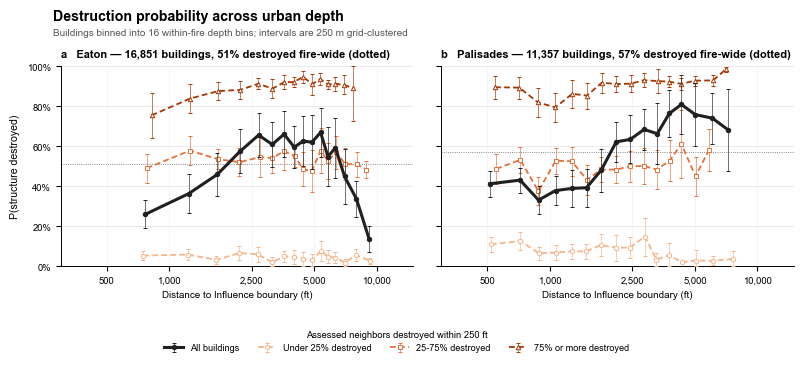

,fire,exposure_class,buildings,median_depth_ft,mean_assessed_neighbors,destroyed_share,any_damage_share,radius_ft
0,EATON,25-75% destroyed,4565,4194.793,32.027,0.527,0.631,250
1,EATON,75% or more destroyed,6535,4108.441,35.757,0.907,0.947,250
2,EATON,No assessed neighbor,16,1820.224,0.000,0.250,0.562,250
3,EATON,Under 25% destroyed,5735,4456.194,27.403,0.044,0.090,250
4,PALISADES,25-75% destroyed,3162,1722.293,20.391,0.491,0.640,250
5,PALISADES,75% or more destroyed,5134,3544.626,34.555,0.917,0.961,250
6,PALISADES,No assessed neighbor,63,440.102,0.000,0.302,0.413,250
7,PALISADES,Under 25% destroyed,2998,1375.093,15.870,0.079,0.151,250


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_fig_destruction_by_depth_250ft.png


In [6]:
WIDE_RADIUS_FT = 250  # expanded from the 100 ft outer Home Ignition Zone
WIDE_RADIUS_M = WIDE_RADIUS_FT / M_TO_FT
DEPTH_PROFILE_BINS = 16
EXPOSURE_CLASSES = [
    ('Under 25% destroyed', 0., .25, '#F6B48A', 'o'),
    ('25-75% destroyed', .25, .75, '#E4703A', 's'),
    ('75% or more destroyed', .75, 1.01, '#A63603', '^'),
]
ALL_BUILDINGS_COLOR = '#202020'

wide_parts = []
for fire_name in FIRES:
    buildings = urban_depth_buildings[
        urban_depth_buildings.fire.eq(fire_name)].copy().reset_index(drop=True)
    pair_idx = buildings.sindex.query(
        buildings.geometry, predicate='dwithin', distance=WIDE_RADIUS_M)
    keep = pair_idx[0] != pair_idx[1]
    focal_i, neighbor_i = pair_idx[0, keep], pair_idx[1, keep]
    neighbor_count = np.bincount(focal_i, minlength=len(buildings)).astype(int)
    destroyed_count = np.bincount(
        focal_i, weights=buildings.is_destroyed.to_numpy(float)[neighbor_i],
        minlength=len(buildings))
    buildings[f'assessed_neighbors_{WIDE_RADIUS_FT}ft'] = neighbor_count
    buildings[f'destroyed_neighbors_{WIDE_RADIUS_FT}ft'] = (
        destroyed_count.astype(int))
    buildings[f'destroyed_neighbor_share_{WIDE_RADIUS_FT}ft'] = np.divide(
        destroyed_count, neighbor_count,
        out=np.full(len(buildings), np.nan, dtype=float),
        where=neighbor_count > 0)
    wide_parts.append(pd.DataFrame(buildings.drop(columns='geometry')))
depth_destruction = pd.concat(wide_parts, ignore_index=True)

wide_share = depth_destruction[f'destroyed_neighbor_share_{WIDE_RADIUS_FT}ft']
depth_destruction['exposure_class'] = 'No assessed neighbor'
for label, low, high, _, _ in EXPOSURE_CLASSES:
    depth_destruction.loc[
        wide_share.ge(low) & wide_share.lt(high), 'exposure_class'] = label

# Depth bins are cut once per fire on the whole assessed population so every
# exposure class is read at the same distances.
depth_destruction = depth_destruction[
    depth_destruction.dist_to_opened_influence_boundary_m.gt(0)].copy()
depth_destruction['depth_ft'] = (
    depth_destruction.dist_to_opened_influence_boundary_m * M_TO_FT)
depth_destruction['ln_depth'] = np.log(depth_destruction.depth_ft)
depth_destruction['depth_bin'] = (
    depth_destruction.groupby('fire').ln_depth
    .transform(lambda values: pd.qcut(
        values, DEPTH_PROFILE_BINS, labels=False, duplicates='drop')))


def _clustered_share(group, column='is_destroyed'):
    """Mean outcome with a 250 m grid-clustered 95% interval."""
    y = group[column].to_numpy(float)
    ybar = float(np.mean(y))
    cluster = group.grid_id.fillna(group.BLD_ID).astype(str)
    scores = (pd.Series(y - ybar, index=group.index)
              .groupby(cluster).sum().to_numpy())
    n_clusters = len(scores)
    se = (np.sqrt(n_clusters / (n_clusters - 1)
                  * np.sum(scores ** 2) / len(group) ** 2)
          if n_clusters > 1 else np.nan)
    return ybar, max(0., ybar - 1.96 * se), min(1., ybar + 1.96 * se), n_clusters


depth_rows = []
for fire_name in FIRES:
    fire_frame = depth_destruction[depth_destruction.fire.eq(fire_name)]
    strata = ([('All buildings', fire_frame)]
              + [(label, fire_frame[fire_frame.exposure_class.eq(label)])
                 for label, *_ in EXPOSURE_CLASSES])
    for label, stratum in strata:
        for depth_bin, group in stratum.groupby('depth_bin', observed=True):
            if len(group) < 30:
                continue
            share, lo, hi, n_clusters = _clustered_share(group)
            depth_rows.append({
                'fire': fire_name, 'stratum': label,
                'radius_ft': WIDE_RADIUS_FT, 'depth_bin': int(depth_bin),
                'buildings': len(group), 'clusters_250m': n_clusters,
                'depth_ft': np.exp(group.ln_depth.mean()),
                'ln_depth': group.ln_depth.mean(),
                'destroyed_share': share, 'share_lo': lo, 'share_hi': hi,
            })
depth_destruction_profile = pd.DataFrame(depth_rows)

depth_destruction_summary = (
    depth_destruction.groupby(['fire', 'exposure_class'], dropna=False)
    .agg(buildings=('BLD_ID', 'size'),
         median_depth_ft=('depth_ft', 'median'),
         mean_assessed_neighbors=(f'assessed_neighbors_{WIDE_RADIUS_FT}ft',
                                  'mean'),
         destroyed_share=('is_destroyed', 'mean'),
         any_damage_share=('any_damage', 'mean'))
    .reset_index())
depth_destruction_summary['radius_ft'] = WIDE_RADIUS_FT

depth_destruction_summary.to_csv(
    RESULTS / 'ED02_destruction_by_depth_250ft.csv', index=False)
depth_destruction_profile.to_csv(
    RESULTS / 'ED02_destruction_by_depth_250ft_profiles.csv', index=False)
depth_destruction_profile.to_csv(
    SOURCE_DATA / 'ED_fig_destruction_by_depth_250ft_source.csv', index=False)

metric_spec = DEPTH_DISPLAY['dist_to_opened_influence_boundary_m']
fig, axes = plt.subplots(1, 2, figsize=(8.1, 3.7), sharey=True)
for col_i, fire_name in enumerate(FIRES):
    ax = axes[col_i]
    series = ([('All buildings', ALL_BUILDINGS_COLOR, 'o', 2.2, '-')]
              + [(label, color, marker, 1.3, (0, (3.2, 1.8)))
                 for label, _, _, color, marker in EXPOSURE_CLASSES])
    for label, color, marker, width, linestyle in series:
        group = depth_destruction_profile[
            depth_destruction_profile.fire.eq(fire_name)
            & depth_destruction_profile.stratum.eq(label)].sort_values('depth_ft')
        if group.empty:
            continue
        yerr = np.vstack([group.destroyed_share - group.share_lo,
                          group.share_hi - group.destroyed_share])
        ax.errorbar(
            group.depth_ft, group.destroyed_share, yerr=np.clip(yerr, 0, None),
            color=color, marker=marker, ms=3.2, mew=.7,
            mfc='white' if label != 'All buildings' else color,
            lw=width, ls=linestyle, elinewidth=.45, capsize=1.2, label=label,
            zorder=4 if label == 'All buildings' else 3)
    pooled = depth_destruction[depth_destruction.fire.eq(fire_name)]
    ax.axhline(pooled.is_destroyed.mean(), color=ALL_BUILDINGS_COLOR, lw=.6,
               ls=':', alpha=.7, zorder=1)
    ax.text(0, 1.035,
            f'{"ab"[col_i]}   {fire_name.title()} — {len(pooled):,} buildings, '
            f'{100 * pooled.is_destroyed.mean():.0f}% destroyed fire-wide '
            f'(dotted)',
            transform=ax.transAxes, ha='left', va='bottom', fontsize=8.0,
            fontweight='bold', clip_on=False)
    ax.set_xscale('log'); ax.set_ylim(0, 1)
    ax.set_xlim(*metric_spec['xlim'])
    ax.set_xticks(metric_spec['ticks'])
    ax.xaxis.set_major_formatter(FixedFormatter(
        [f'{value:,}' for value in metric_spec['ticks']]))
    ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.set_xlabel(metric_spec['label'], labelpad=4, fontsize=7.1)
    ax.grid(axis='y', color='#D7D7D7', lw=.5, alpha=.75)
    ax.grid(axis='x', color='#E5E5E5', lw=.4, alpha=.65)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=6.8)
axes[0].set_ylabel('P(structure destroyed)', labelpad=5, fontsize=7.6)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc='lower center',
           bbox_to_anchor=(.5, .045), ncol=4, fontsize=6.6,
           title=f'Assessed neighbors destroyed within {WIDE_RADIUS_FT} ft',
           title_fontsize=6.8)
fig.suptitle('Destruction probability across urban depth', x=.075, ha='left',
             y=.995, fontsize=10.2, fontweight='bold')
fig.text(.075, .925,
         f'Buildings binned into {DEPTH_PROFILE_BINS} within-fire depth bins; '
         f'intervals are 250 m grid-clustered',
         ha='left', fontsize=7.2, color='#555555')
fig.subplots_adjust(left=.085, right=.99, top=.84, bottom=.30, wspace=.08)
depth_stem = FIGURES / 'ED_fig_destruction_by_depth_250ft'
fig.savefig(depth_stem.with_suffix('.pdf'), bbox_inches='tight')
fig.savefig(depth_stem.with_suffix('.png'), dpi=300, bbox_inches='tight')
plt.show()
display(depth_destruction_summary.round(3))
print('saved', depth_stem.with_suffix('.png'))

## Realized coupling versus damaged-neighbor count

For each assessed structure, neighboring structures with partial damage or destruction are counted within 100, 250, 500 and 1,000 ft. Counts use centroid locations in EPSG:2229 and exclude the focal building itself. Within each fire and outcome, the figure shows geometric-mean $F^*$ across equal-quantile neighbor-count bins with 95% confidence intervals and a LOWESS summary.

,fire,radius_ft,matched_strata,destroyed_to_surviving_F_star_ratio
0,EATON,100,5,2.805
1,EATON,250,10,3.843
2,EATON,500,10,7.128
3,EATON,1000,10,10.776
4,PALISADES,100,3,4.731
5,PALISADES,250,8,4.546
6,PALISADES,500,9,6.702
7,PALISADES,1000,9,11.290


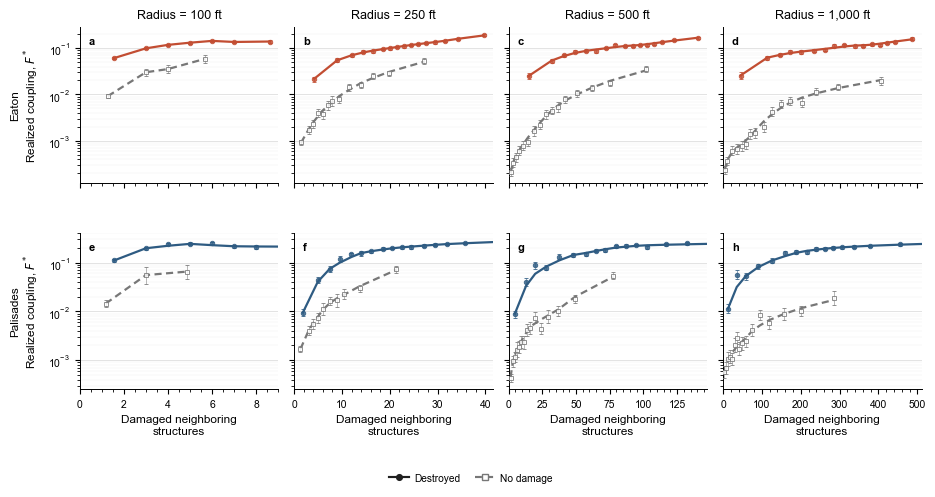

In [7]:
manifest = json.loads((RESULTS / 'analysis_manifest.json').read_text())
analysis_path = DATA / 'analysis.parquet'
assert sha256(analysis_path) == manifest['inputs']['analysis']['sha256']
analysis = pd.read_parquet(analysis_path)
neighbor_data = attach_damaged_neighbor_counts(
    analysis, radii_ft=DEFAULT_RADII_FT
)
binned, smooth, outcome_gap = neighborhood_exposure_summary(
    neighbor_data, radii_ft=DEFAULT_RADII_FT
)
outcome_gap.to_csv(
    RESULTS / 'ED_neighbor_radius_outcome_gap.csv', index=False
)
display(outcome_gap.round(3))
plot_neighbor_radius_sweep(
    binned, smooth, DEFAULT_RADII_FT, FIGURES, SOURCE_DATA
);

## Four- versus five-parameter fragility curves

The symmetric four-parameter logistic curve fixes the asymmetry parameter to one. The five-parameter curve estimates it. Both model forms are fit to the complete exposed population; predictive performance is then compared using ten folds defined by approximately 250-m spatial grid cells. Lower held-out log loss indicates better probability calibration.

In [8]:
model_form, model_cv, model_predictions = compare_4pl_5pl(analysis)
model_form.to_csv(RESULTS / 'ED02_fragility_model_form.csv', index=False)
model_cv.to_csv(RESULTS / 'ED02_fragility_model_form_spatial_cv.csv', index=False)
model_predictions.to_csv(
    RESULTS / 'ED02_fragility_model_form_predictions.csv', index=False)
display(model_form.round(5))
display(model_cv.round(5))
plot_4pl_5pl_comparison(
    analysis, model_form, model_cv, FIGURES, SOURCE_DATA
);

,fire,model,n,p_min,p_max,k,hill,asymmetry,f50,in_sample_log_loss,in_sample_brier
0,EATON,4PL,14595,0.03163,0.93598,0.02286,1.81659,1.00000,0.02286,0.36759,0.11164
1,EATON,5PL,14595,0.02567,0.92745,0.02997,2.09208,0.68145,0.02284,0.36740,0.11162
2,PALISADES,4PL,10532,0.10948,1.00000,0.03749,1.33483,1.00000,0.03749,0.38912,0.12025
3,PALISADES,5PL,10532,0.05590,0.96034,0.10542,2.81487,0.21686,0.03437,0.38703,0.11971


,fire,model,n_predicted,spatial_cv_log_loss,spatial_cv_brier
0,EATON,4PL,14595,0.36799,0.11179
1,EATON,5PL,14595,0.36783,0.11177
2,PALISADES,4PL,10532,0.39012,0.12054
3,PALISADES,5PL,10532,0.38823,0.12003


## Interpretation

At comparable damaged-neighbor counts, destroyed structures retain greater $F^*$ than structures with no recorded damage. Persistence across radii indicates that a neighborhood count does not recover the surface area, orientation, separation and occlusion represented by geometric coupling. The five-parameter curve changes Eaton's $F_{50}$ negligibly relative to the symmetric curve and shifts the Palisades estimate downward from 0.0375 to 0.0344. Its spatially held-out log loss is slightly lower in both fires, with the larger gain in Palisades. The added asymmetry is therefore modestly supported, while the main cross-fire threshold difference does not depend on the five-parameter form.